# Exploratory Data Analysis (EDA)

## Scope of This Notebook

This notebook performs **univariate and bivariate exploration** — understanding distributions, segments, and relationships in the cleaned dataset.

Unlike **Notebook 5 (Advanced Business Insights)**, which builds composite scores for brand prioritization, EDA focuses on *what the data looks like* before deriving actionable rankings.

**Input:** `data/myntra_cleaned.csv` (31,527 products after deduplication and discount-format cleaning)

## Business Questions

1. What is the price distribution of men's jeans on Myntra?
2. Which brands have the highest average prices?
3. How do customer ratings vary across price segments?
4. Which brands dominate the budget segment?
5. How are products distributed across price categories?

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')
sns.set_palette('husl')


In [2]:
df = pd.read_csv("../data/myntra_cleaned.csv")
df.head()

,brand_name,pants_description,price,MRP,discount_percent,ratings,number_of_ratings
0,WROGN,Men Loose Fit Cotton Jeans,1374.0,2499.0,0.45,4.2,57.0
1,Flying Machine,Men Slim Fit Jeans,1829.0,2999.0,0.39,4.6,5.0
2,Roadster,Men Pure Cotton Jeans,974.0,2499.0,0.61,3.6,1100.0
3,Bene Kleed,Relaxed Fit Denim Jeans,873.0,2299.0,0.62,4.0,4800.0
4,Levis,Men 511 Slim Fit Jeans,1478.0,2899.0,0.49,4.3,264.0


In [3]:
summary = {
    "total_products": len(df),
    "unique_brands": df["brand_name"].nunique(),
    "avg_price": df["price"].mean(),
    "median_price": df["price"].median(),
    "avg_rating": df["ratings"].mean(),
    "avg_discount_pct": df["discount_percent"].mean() * 100,
}
print("Dataset Summary:")
for k, v in summary.items():
    if isinstance(v, float):
        print(f"  {k}: {v:,.2f}")
    else:
        print(f"  {k}: {v:,}")

Dataset Summary:
  total_products: 31,527
  unique_brands: 371
  avg_price: 1,696.51
  median_price: 1,484.00
  avg_rating: 3.98
  avg_discount_pct: 50.34


---

## BQ1 — Price Distribution

What is the price distribution of men's jeans on Myntra?

In [4]:
df["price"].describe()

count    31527.000000
mean      1696.510071
std       1826.603792
min        337.000000
25%        989.000000
50%       1484.000000
75%       1886.000000
max      54000.000000
Name: price, dtype: float64

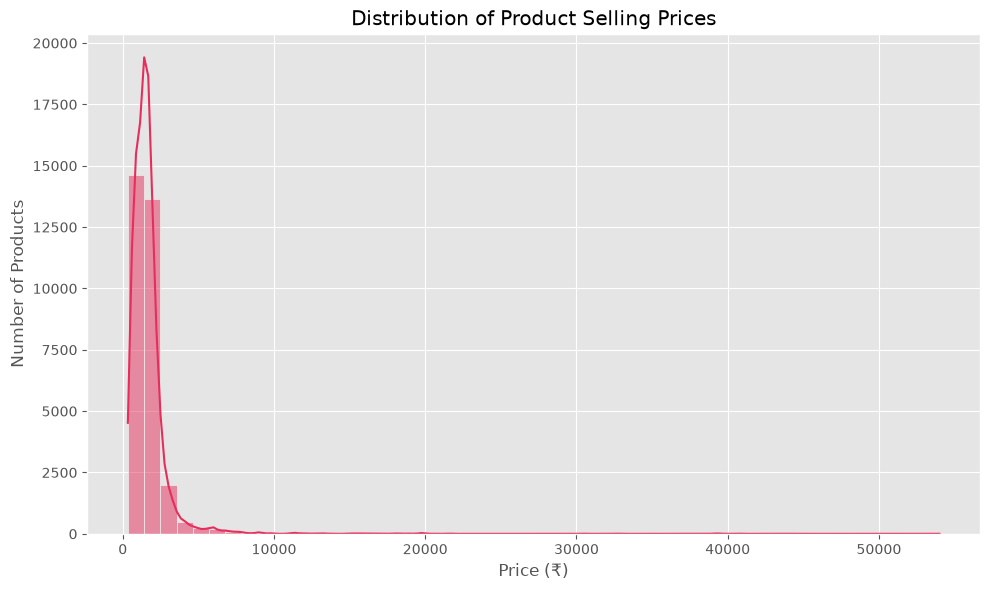

In [5]:
plt.figure(figsize=(10, 6))
sns.histplot(df["price"], bins=50, kde=True, color="#E62E5C")
plt.title("Distribution of Product Selling Prices")
plt.xlabel("Price (₹)")
plt.ylabel("Number of Products")
plt.tight_layout()
plt.savefig("../images/eda_price_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

### Observation & Insight

The price distribution is **right-skewed**: the median (₹1,484) sits below the mean (₹1,697), driven by a long tail of premium and luxury items. Most products cluster in the mid-range segment, which is typical for mass-market fashion e-commerce.

## BQ2 — Highest-Priced Brands

Which brands have the highest average prices?

In [6]:
brand_avg_price = (
    df.groupby("brand_name")["price"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)
brand_avg_price

brand_name
Jacob Cohen              33142.500000
Tramarossa               23143.315789
Karl Lagerfeld           18487.500000
Just Cavalli             18149.000000
Versace Jeans Couture    17210.125000
7 For All Mankind        16000.500000
HACKETT LONDON           14220.500000
Polo Ralph Lauren        11656.444444
True Religion            11340.073394
TRAVIS MATHEW             8243.000000
Name: price, dtype: float64

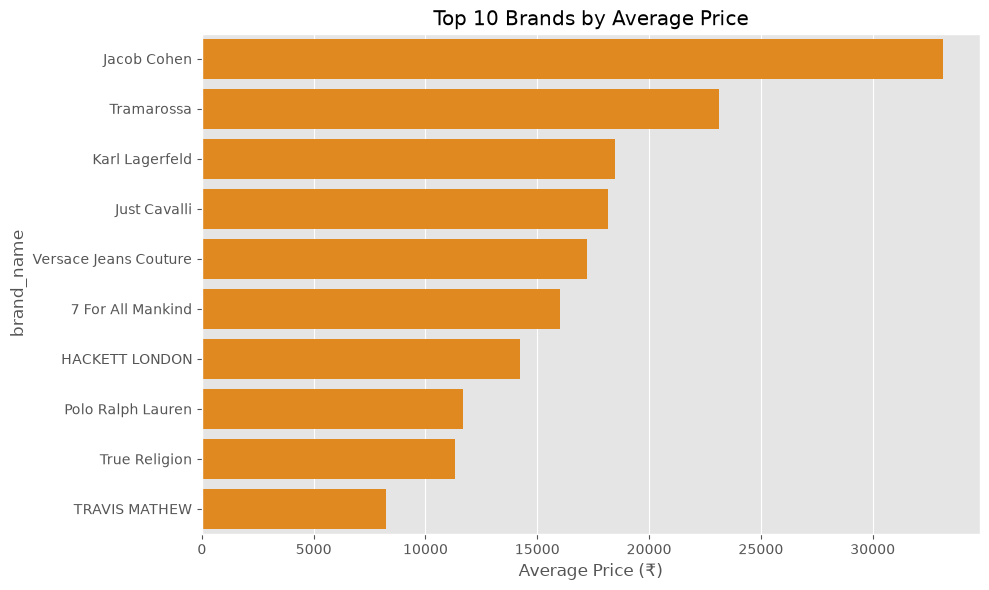

In [7]:
plt.figure(figsize=(10, 6))
sns.barplot(x=brand_avg_price.values, y=brand_avg_price.index, color='darkorange')
plt.title("Top 10 Brands by Average Price")
plt.xlabel("Average Price (₹)")
plt.tight_layout()
plt.savefig("../images/eda_top_brands_price.png", dpi=120, bbox_inches="tight")
plt.show()

### Observation & Insight

Premium and designer labels dominate the highest average-price tier. These brands serve a niche luxury segment and should be merchandised separately from mass-market offerings.

## BQ3 — Ratings Across Price Segments

How do customer ratings vary across price segments?

In [8]:
PRICE_BINS = [0, 500, 1000, 2000, 5000, float("inf")]
PRICE_LABELS = ["≤₹500", "₹501–1000", "₹1001–2000", "₹2001–5000", ">₹5000"]

df["price_segment"] = pd.cut(df["price"], bins=PRICE_BINS, labels=PRICE_LABELS)
segment_rating = (
    df.groupby("price_segment", observed=True)["ratings"]
    .agg(['mean', 'count'])
    .round(2)
)
segment_rating

,mean,count
price_segment,,
≤₹500,3.78,549
₹501–1000,3.87,7829
₹1001–2000,4.01,16531
₹2001–5000,4.04,5996
>₹5000,4.11,622


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_17192\1589631603.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="price_segment", y="ratings", palette="Blues")


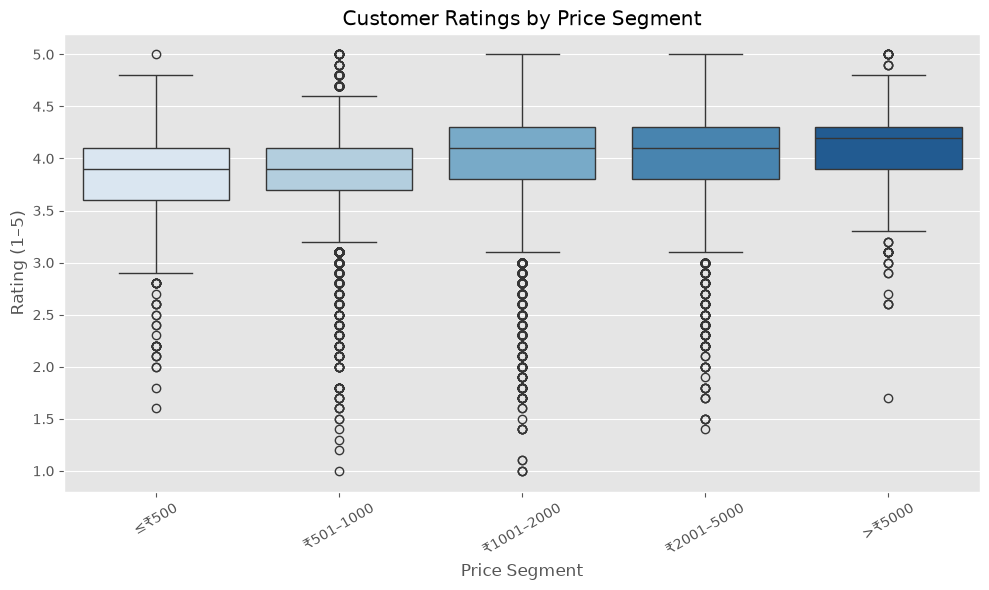

In [9]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="price_segment", y="ratings", palette="Blues")
plt.title("Customer Ratings by Price Segment")
plt.xlabel("Price Segment")
plt.ylabel("Rating (1–5)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("../images/eda_ratings_by_segment.png", dpi=120, bbox_inches="tight")
plt.show()

### Observation & Insight

Ratings are relatively stable across segments, with a slight uplift in premium tiers. The **₹1,001–2,000 segment** combines high volume with solid ratings — the core commercial sweet spot.

## BQ4 — Budget Segment Leaders

Which brands dominate the budget segment?

In [10]:
budget = df[df["price_segment"] == "≤₹500"]
budget_brands = (
    budget.groupby("brand_name")
    .agg(products=("price", "count"), avg_price=("price", "mean"))
    .sort_values('products', ascending=False)
    .head(10)
    .round(2)
)
budget_brands

,products,avg_price
brand_name,,
MaverIQ,108,461.70
glitchez,107,467.68
Roadster,83,472.95
United Colors of Benetton,54,458.13
Moda Rapido,44,479.91
SZN,36,405.97
Mast & Harbour,15,496.60
V-Mart,14,459.00
LOCOMOTIVE,12,444.50


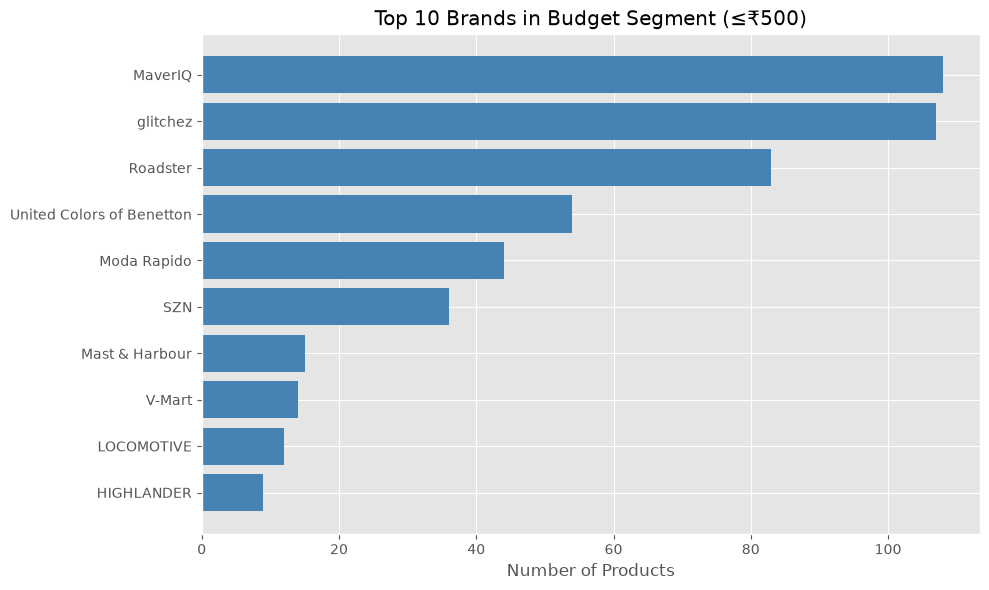

In [11]:
plt.figure(figsize=(10, 6))
top_budget = budget_brands['products'].sort_values()
plt.barh(top_budget.index, top_budget.values, color='steelblue')
plt.title("Top 10 Brands in Budget Segment (≤₹500)")
plt.xlabel("Number of Products")
plt.tight_layout()
plt.savefig("../images/eda_budget_brands.png", dpi=120, bbox_inches="tight")
plt.show()

### Observation & Insight

A handful of value-oriented brands account for most budget listings. Myntra can use this segment for acquisition campaigns and entry-level customer onboarding.

## BQ5 — Price Category Distribution

How are products distributed across price categories?

In [12]:
CATEGORY_BINS = [0, 1000, 2000, 3000, 5000, 60000]
CATEGORY_LABELS = ["Budget", "Economy", "Mid-Range", "Premium", "Luxury"]

df["price_category"] = pd.cut(
    df["price"], bins=CATEGORY_BINS, labels=CATEGORY_LABELS
)
category_counts = df['price_category'].value_counts().reindex(CATEGORY_LABELS)
category_counts

price_category
Budget        8378
Economy      16531
Mid-Range     4756
Premium       1240
Luxury         622
Name: count, dtype: int64

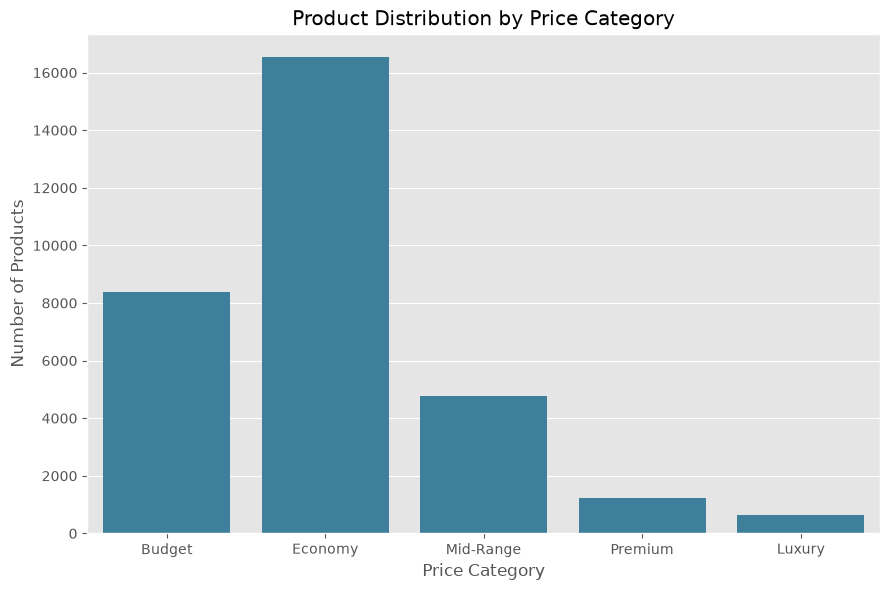

In [13]:
plt.figure(figsize=(9, 6))
sns.countplot(data=df, x='price_category', order=CATEGORY_LABELS, color='#2E86AB')
plt.title("Product Distribution by Price Category")
plt.xlabel("Price Category")
plt.ylabel("Number of Products")
plt.tight_layout()
plt.savefig("../images/eda_price_categories.png", dpi=120, bbox_inches="tight")
plt.show()

### Observation & Insight

The catalog is concentrated in **Economy and Mid-Range** categories. Luxury represents a small fraction but extends the price range significantly.

---

## Supplementary — Brand Engagement & Discounts

### Top Brands by Customer Engagement

In [14]:
brand_engagement = (
    df.groupby("brand_name")
    .agg(
        products=("price", "count"),
        total_ratings=("number_of_ratings", "sum"),
        avg_rating=("ratings", "mean"),
    )
    .sort_values('total_ratings', ascending=False)
    .head(10)
    .round(2)
)
brand_engagement

,products,total_ratings,avg_rating
brand_name,,,
Roadster,1794,531537.0,3.87
United Colors of Benetton,2982,335797.0,4.03
Flying Machine,2573,274996.0,3.98
HIGHLANDER,285,273136.0,3.83
WROGN,1100,148318.0,4.00
Levis,563,105384.0,4.22
The Indian Garage Co,372,94793.0,3.95
Urbano Fashion,274,80448.0,3.89
Mast & Harbour,558,76187.0,3.78


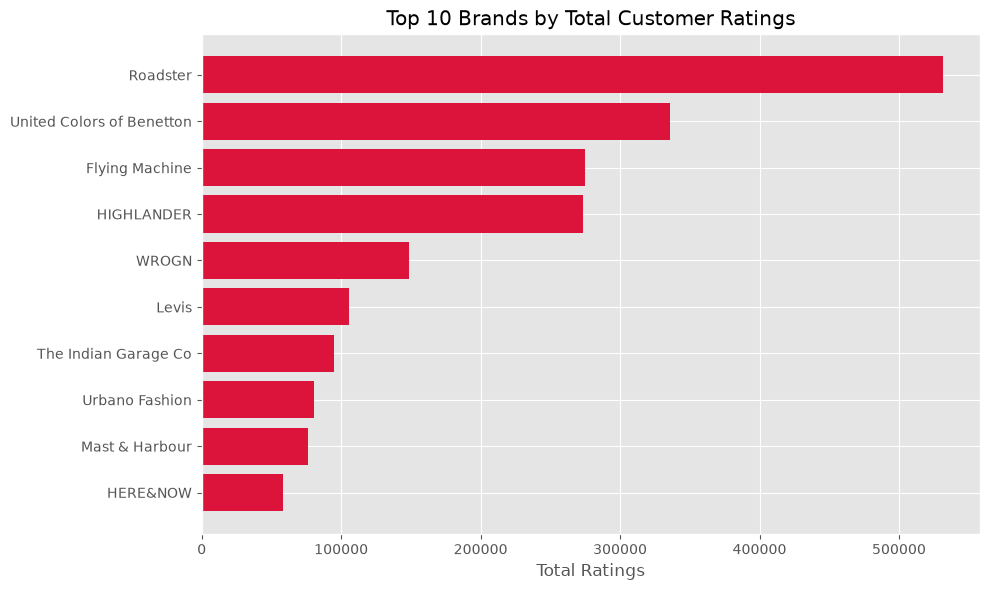

In [15]:
top = brand_engagement.sort_values('total_ratings')
plt.figure(figsize=(10, 6))
plt.barh(top.index, top['total_ratings'], color='crimson')
plt.title("Top 10 Brands by Total Customer Ratings")
plt.xlabel("Total Ratings")
plt.tight_layout()
plt.savefig("../images/eda_brand_engagement.png", dpi=120, bbox_inches="tight")
plt.show()

### Discount Distribution

In [16]:
print(f"Average discount: {df['discount_percent'].mean() * 100:.1f}%")
print(f"Median discount:  {df['discount_percent'].median() * 100:.1f}%")

Average discount: 50.3%
Median discount:  51.0%


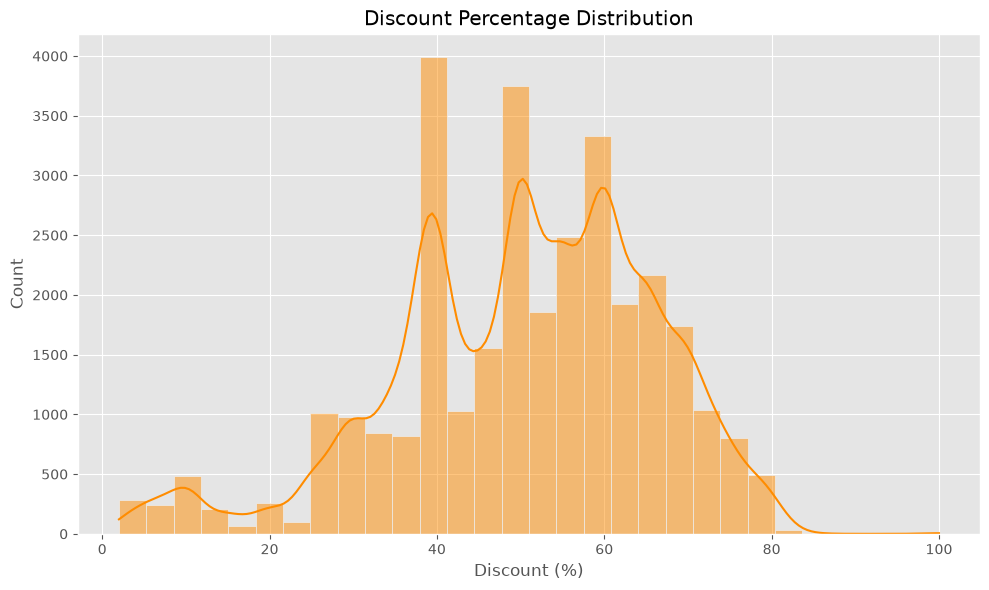

In [17]:
plt.figure(figsize=(10, 6))
sns.histplot(df["discount_percent"] * 100, bins=30, kde=True, color="darkorange")
plt.title("Discount Percentage Distribution")
plt.xlabel("Discount (%)")
plt.tight_layout()
plt.savefig("../images/eda_discount_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

### Price vs. Rating Correlation

In [18]:
corr = df["price"].corr(df["ratings"])
print(f"Price–Rating correlation: {corr:.3f}")

Price–Rating correlation: 0.089


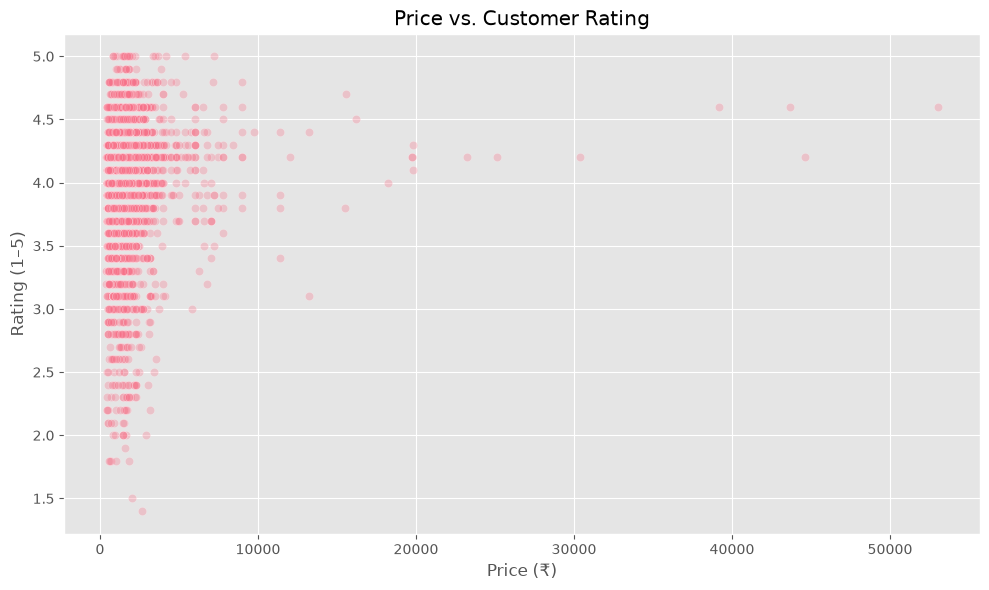

In [19]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df.sample(min(5000, len(df))), x="price", y="ratings", alpha=0.3)
plt.title("Price vs. Customer Rating")
plt.xlabel("Price (₹)")
plt.ylabel("Rating (1–5)")
plt.tight_layout()
plt.savefig("../images/eda_price_rating_scatter.png", dpi=120, bbox_inches="tight")
plt.show()

---

## EDA Conclusions

- **Pricing:** Mid-range (₹1,001–2,000) is the commercial core; distribution is right-skewed.
- **Brands:** Roadster, HIGHLANDER, and value labels lead engagement; premium brands anchor the top price tier.
- **Ratings:** Stable across segments; no strong price–rating linear relationship.
- **Discounts:** Average ~50% off; heavy promotional activity across the catalog.

→ Proceed to **Notebook 5** for composite Value Score and Business Performance Score rankings.